# **Inverse design of photonic crystals**

This notebook demonstrates a gradient-based optimization approach to solving an inverse problem in photonics: designing a multilayer structure (Bragg stack) that produces a desired optical response.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
# ---------------------------
# TMM
# ---------------------------
def tmm_1d_RT(wavelengths, n_layers, d_layers):
    # Ensure d_layers is a tensor to access .device
    if not isinstance(d_layers, torch.Tensor):
        d_layers = torch.tensor(d_layers, dtype=torch.float32)

    device = d_layers.device
    wavelengths = torch.tensor(wavelengths, dtype=torch.float32, device=device)

    n_in = torch.tensor(1.0, dtype=torch.complex64, device=device)
    n_out = torch.tensor(1.0, dtype=torch.complex64, device=device)

    R = []

    for wl in wavelengths:
        k0 = 2 * torch.pi / wl
        M = torch.eye(2, dtype=torch.complex64, device=device)

        for n, d in zip(n_layers, d_layers):
            # Ensure n is a tensor before creating a complex tensor
            if not isinstance(n, torch.Tensor):
                n = torch.tensor(n, dtype=torch.float32, device=device)

            n_c = torch.complex(n, torch.tensor(0.0, device=device))
            d_c = torch.complex(d, torch.tensor(0.0, device=device))

            delta = k0 * n_c * d_c
            cos_d = torch.cos(delta)
            sin_d = torch.sin(delta)

            m = torch.stack([
                torch.stack([cos_d, 1j * sin_d / n_c]),
                torch.stack([1j * n_c * sin_d, cos_d])
            ])
            M = M @ m

        denom = (M[0,0] + M[0,1]*n_out)*n_in + (M[1,0] + M[1,1]*n_out)
        r = ((M[0,0] + M[0,1]*n_out)*n_in - (M[1,0] + M[1,1]*n_out)) / denom

        R.append(torch.abs(r)**2)

    return torch.stack(R)

In [4]:
# ---------------------------
# Inverse Design (Optimization)
# ---------------------------
def inverse_design(wl, R_target, num_layers=10, steps=1000, lr=0.05):
    device = torch.device("cpu")

    # Initialize thickness (logit parameterization)
    logits = torch.randn(num_layers, requires_grad=True, device=device)
    optimizer = torch.optim.Adam([logits], lr=lr)

    # Material indices
    n_layers = torch.tensor(
        [1.45 if i % 2 == 0 else 2.0 for i in range(num_layers)],
        dtype=torch.float32, device=device
    )

    R_target = torch.tensor(R_target, dtype=torch.float32, device=device)

    for step in tqdm(range(steps)):
        optimizer.zero_grad()

        # Thickness constraint: 10–100 nm
        d = 10 + 90 * torch.sigmoid(logits)

        # Forward physics
        R_pred = tmm_1d_RT(wl, n_layers, d)

        # Loss
        loss = torch.mean((R_pred - R_target)**2)

        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(f"Step {step}: Loss = {loss.item():.6f}")

    return d.detach().cpu().numpy()

In [5]:
# ---------------------------
# Define Target Spectrum
# ---------------------------
wl = np.linspace(300, 800, 200)

center = 550
bandwidth = 75

R_target = np.full_like(wl, 0.01)
mask = (wl >= center - bandwidth/2) & (wl <= center + bandwidth/2)
R_target[mask] = 0.99

In [6]:
# ---------------------------
# Run Inverse Design
# ---------------------------
%%time

num_layers = 10

d_opt = inverse_design(wl, R_target, num_layers=num_layers)

# Convert n_layers and d_opt to torch tensors before passing to tmm_1d_RT
n_layers_tensor = torch.tensor([1.45 if i % 2 == 0 else 2.0 for i in range(num_layers)], dtype=torch.float32)
d_opt_tensor = torch.tensor(d_opt, dtype=torch.float32)
R_result = tmm_1d_RT(wl, n_layers_tensor, d_opt_tensor)

  0%|          | 1/1000 [00:00<14:45,  1.13it/s]

Step 0: Loss = 0.138836


 10%|█         | 101/1000 [01:33<15:53,  1.06s/it]

Step 100: Loss = 0.055517


 20%|██        | 201/1000 [03:03<13:06,  1.02it/s]

...

Step 800: Loss = 0.054790


 90%|█████████ | 901/1000 [13:40<01:26,  1.15it/s]

Step 900: Loss = 0.054784


100%|██████████| 1000/1000 [15:10<00:00,  1.10it/s]


CPU times: user 15min 6s, sys: 1.66 s, total: 15min 7s
Wall time: 15min 16s


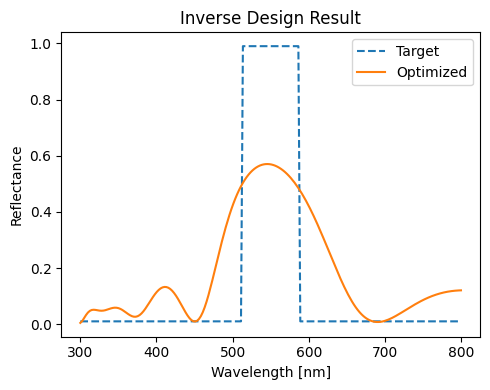

In [7]:
# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(5,4))

plt.subplot(1,1,1)
plt.plot(wl, R_target, '--', label="Target")
plt.plot(wl, R_result.cpu().numpy(), label="Optimized") # Convert R_result to numpy for plotting
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reflectance")
plt.legend()
plt.title("Inverse Design Result")

plt.tight_layout()
plt.show()